# Medical Abstracts TC Corpus — Baseline Text Classification

This notebook establishes the first machine learning baseline for the Medical Abstracts TC Corpus.

The objective is not to optimize model performance yet. Instead, the goal is to create a simple, reproducible, and interpretable reference model that future experiments can be compared against.

The modeling task is formulated as a single-label multiclass text classification problem:

- **Input:** `medical_abstract`
- **Target:** `condition_label`
- **Number of classes:** 5

The processed datasets produced in the previous notebook are used directly. The training set is used to fit the model, while the validation set is used to evaluate the baseline.

The test set is intentionally kept isolated and will only be used after model selection is complete.

Two baselines are evaluated:

1. A `DummyClassifier`, representing performance without learning useful patterns from the text.
2. A TF-IDF + Logistic Regression pipeline, representing the first real text classification model.

## 1. Environment setup

The required libraries and project constants are defined in this section.

A fixed random state is used whenever randomness is involved so that experiments can be reproduced consistently.

The text and target column names are also defined as constants to avoid duplicating column names throughout the notebook.

In [18]:
from pathlib import Path

import pandas as pd

from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
)
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42

TEXT_COL = "medical_abstract"
TARGET_COL = "condition_label"

### Project paths

The notebook resolves the project root dynamically so that it can be executed either from the repository root or directly from the `notebooks/` directory.

Only processed datasets are used during modeling. Raw data preparation and cleaning remain isolated in the previous dataset preparation stage.

In [2]:
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

print("Processed data directory:", PROCESSED_DATA_DIR)

Processed data directory: /home/mkiku/Medical-Triage/data/processed


## 2. Loading the processed datasets

The training and validation datasets generated by the dataset preparation notebook are loaded here.

The training set will be used to learn both the text representation and the classifier parameters.

The validation set will be used to estimate how well the model generalizes to unseen examples and to support model selection decisions.

The test dataset is deliberately not loaded at this stage. Keeping the test set isolated helps prevent decisions about preprocessing, model choice, or hyperparameters from being influenced by final evaluation results.

In [3]:
TRAIN_PATH = PROCESSED_DATA_DIR / "train.csv"
VALIDATION_PATH = PROCESSED_DATA_DIR / "validation.csv"
LABELS_PATH = PROCESSED_DATA_DIR / "labels.csv"

train_df = pd.read_csv(TRAIN_PATH)
validation_df = pd.read_csv(VALIDATION_PATH)
labels_df = pd.read_csv(LABELS_PATH)

print("Training shape:", train_df.shape)
print("Validation shape:", validation_df.shape)

Training shape: (5808, 2)
Validation shape: (1245, 2)


## 3. Dataset sanity checks

Before training a model, the processed datasets are validated again.

Although data quality checks were already performed during dataset preparation, lightweight validation at the modeling boundary helps detect unexpected changes in the input data.

The following conditions are checked:

- required columns are present;
- text and target values are not missing;
- all expected classes are present;
- training and validation contain no overlapping medical abstracts.

In [4]:
required_columns = {TEXT_COL, TARGET_COL}

assert required_columns.issubset(train_df.columns)
assert required_columns.issubset(validation_df.columns)

assert train_df[[TEXT_COL, TARGET_COL]].notna().all().all()
assert validation_df[[TEXT_COL, TARGET_COL]].notna().all().all()

print(
    "Training classes:",
    sorted(train_df[TARGET_COL].unique())
)

print(
    "Validation classes:",
    sorted(validation_df[TARGET_COL].unique())
)

Training classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Validation classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [5]:
train_texts = set(train_df[TEXT_COL])
validation_texts = set(validation_df[TEXT_COL])

assert train_texts.isdisjoint(validation_texts)

print("Training and validation sets contain no overlapping texts.")

Training and validation sets contain no overlapping texts.


## 4. Preparing features and targets

The input feature is the medical abstract text, while the target is the corresponding medical condition label.

In machine learning notation:

- `X` represents the model inputs;
- `y` represents the target values.

Separate training and validation variables are created so that the model can learn exclusively from the training data and be evaluated independently on unseen validation examples.

In [6]:
X_train = train_df[TEXT_COL]
y_train = train_df[TARGET_COL]

X_validation = validation_df[TEXT_COL]
y_validation = validation_df[TARGET_COL]

print("Training samples:", len(X_train))
print("Validation samples:", len(X_validation))

Training samples: 5808
Validation samples: 1245


## 5. Evaluation strategy

The dataset is moderately imbalanced, with some medical condition classes containing substantially fewer samples than others.

Because of this imbalance, accuracy alone is not sufficient to evaluate model quality.

Two main metrics are used:

### Accuracy

Accuracy measures the proportion of predictions that are correct across all validation samples.

While intuitive, it can hide poor performance on minority classes.

### Macro F1-score

Macro F1 calculates the F1-score independently for each class and then computes their unweighted average.

This means that every class contributes equally to the final score, regardless of how many examples it contains.

For this reason, **Macro F1 is treated as the primary model selection metric**, while accuracy is reported as a complementary metric.

## 6. Dummy baseline

Before training a real text classifier, a trivial baseline is established using `DummyClassifier`.

The classifier uses the `most_frequent` strategy, meaning that it always predicts the most common class observed in the training dataset.

This model does not learn any relationship between the medical abstract and the target label.

Its purpose is to establish the minimum performance that a useful machine learning model should clearly outperform.

In [7]:
dummy_model = DummyClassifier(
    strategy="most_frequent",
    random_state=RANDOM_STATE,
)

In [8]:
dummy_model.fit(
    X_train.to_frame(),
    y_train,
)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
Name,Type,Value
"class_prior_ class_prior_: ndarray of shape (n_classes,) or list of such arraysFrequency of each class observed in `y`. For multioutput classificationproblems, this is computed independently for each output.","ndarray[float64](5,)","[0.26,0.08,0.13,0.24,0.29]"
"classes_ classes_: ndarray of shape (n_classes,) or list of such arraysUnique class labels observed in `y`. For multi-output classificationproblems, this attribute is a list of arrays as each output has anindependent set of possible classes.","ndarray[int64](5,)","[1,2,3,4,5]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X` hasfeature names that are all strings.","ndarray[object](1,)",['medical_abstract']
n_classes_ n_classes_: int or list of intNumber of label for each output.,int,5
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,1
n_outputs_ n_outputs_: intNumber of outputs.,int,1
sparse_output_ sparse_output_: boolTrue if the array returned from predict is to be in sparse CSC format.Is automatically set to True if the input `y` is passed in sparseformat.,bool,False


In [9]:
dummy_predictions = dummy_model.predict(
    X_validation.to_frame()
)

In [10]:
dummy_accuracy = accuracy_score(
    y_validation,
    dummy_predictions,
)

dummy_macro_f1 = f1_score(
    y_validation,
    dummy_predictions,
    average="macro",
)

print(f"Dummy Accuracy: {dummy_accuracy:.4f}")
print(f"Dummy Macro F1: {dummy_macro_f1:.4f}")

Dummy Accuracy: 0.2884
Dummy Macro F1: 0.0895


## 7. TF-IDF + Logistic Regression baseline

The first real text classification baseline combines two components:

1. **TF-IDF vectorization**
2. **Logistic Regression**

### TF-IDF

Machine learning models such as Logistic Regression cannot directly process raw text.

TF-IDF converts each medical abstract into a numerical sparse vector based on the words that appear in the corpus.

The representation gives more importance to terms that are frequent within a document but less common across the full training corpus.

This provides a lightweight and efficient representation of medical text without requiring a neural language model.

### Logistic Regression

Logistic Regression is used as the first supervised classifier.

Despite its name, Logistic Regression is commonly used for classification and can naturally support multiclass problems.

It is a strong baseline for high-dimensional sparse text representations such as TF-IDF because it is computationally efficient, relatively simple, and provides a useful reference before experimenting with more complex models.

### Modeling pipeline

TF-IDF and Logistic Regression are combined using a Scikit-Learn `Pipeline`.

The pipeline ensures that text transformation and classification are treated as a single modeling workflow.

During training:

1. TF-IDF learns its vocabulary and document-frequency statistics exclusively from the training data.
2. The training texts are transformed into numerical vectors.
3. Logistic Regression learns the relationship between those vectors and the target labels.

During validation, the already-fitted TF-IDF transformer is only used to transform unseen text.

This separation is important because information from the validation set must not influence the representation learned during training.

In [11]:
baseline_model = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(),
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

## 9. Training the baseline model

The pipeline is fitted using only the training dataset.

Calling `fit()` causes the TF-IDF vectorizer to learn its vocabulary from the training abstracts and transforms them into numerical features.

The transformed features are then used to train the Logistic Regression classifier.

No validation examples participate in this process.

In [12]:
baseline_model.fit(
    X_train,
    y_train,
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](5,)","[1,2,3,4,5]"
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True


## 10. Generating validation predictions

After training, the fitted pipeline is applied to the validation dataset.

At this stage, TF-IDF does not learn a new vocabulary. It transforms the validation texts using the representation learned from the training data.

The resulting vectors are then passed to the trained Logistic Regression classifier to generate predicted condition labels.

In [14]:
validation_predictions = baseline_model.predict(
    X_validation
)

## 11. Baseline evaluation

The model is evaluated on the validation set using both accuracy and Macro F1-score.

The results are compared against the DummyClassifier baseline.

A useful text classifier should substantially outperform the dummy model, demonstrating that the model is learning meaningful relationships between medical terminology and the target categories.

In [15]:
validation_accuracy = accuracy_score(
    y_validation,
    validation_predictions,
)

validation_macro_f1 = f1_score(
    y_validation,
    validation_predictions,
    average="macro",
)

print(f"Validation Accuracy: {validation_accuracy:.4f}")
print(f"Validation Macro F1: {validation_macro_f1:.4f}")

Validation Accuracy: 0.7815
Validation Macro F1: 0.7553


### Baseline comparison

The dummy and machine learning baselines are compared directly.

This comparison helps answer the first important modeling question:

> Does the text classifier actually learn useful predictive patterns from the medical abstracts?

At this stage, the focus is not on maximizing performance. The goal is to establish a reliable reference point for future experiments.

In [16]:
results = pd.DataFrame(
    {
        "model": [
            "Dummy - Most Frequent",
            "TF-IDF + Logistic Regression",
        ],
        "accuracy": [
            dummy_accuracy,
            validation_accuracy,
        ],
        "macro_f1": [
            dummy_macro_f1,
            validation_macro_f1,
        ],
    }
)

results

,model,accuracy,macro_f1
0,Dummy - Most Frequent,0.288353,0.089526
1,TF-IDF + Logistic Regression,0.781526,0.755347


### Initial baseline results

The TF-IDF + Logistic Regression model substantially outperforms the trivial baseline.

The `DummyClassifier`, which always predicts the most frequent class, achieves approximately 28.8% accuracy and a very low Macro F1-score. This confirms that simply exploiting the class distribution is not sufficient for this classification task.

The TF-IDF + Logistic Regression pipeline achieves approximately:

- **78.2% validation accuracy**
- **75.5% Macro F1-score**

The large improvement over the dummy baseline indicates that the model is learning meaningful relationships between the vocabulary used in the medical abstracts and the corresponding condition categories.

The Macro F1-score is slightly lower than accuracy, suggesting that performance may vary across classes. Therefore, aggregate metrics alone are not sufficient to understand model behavior.

The next step is to analyze precision, recall, and F1-score independently for each medical condition class.

## 12. Per-class performance analysis

Aggregate metrics summarize overall model performance but do not show how predictions are distributed across individual medical condition categories.

This is particularly important for this dataset because the target distribution is imbalanced.

A classification report is therefore generated to examine three metrics independently for each class:

- **Precision:** among the samples predicted as a given class, how many were correct;
- **Recall:** among the samples that actually belong to a given class, how many were successfully identified;
- **F1-score:** the harmonic mean of precision and recall.

This analysis helps identify whether the baseline performs consistently across all five classes or whether specific medical categories remain difficult to classify.

In [19]:
label_mapping = (
    labels_df
    .sort_values(TARGET_COL)
    .set_index(TARGET_COL)["condition_name"]
    .to_dict()
)

label_mapping

{1: 'neoplasms',
 2: 'digestive system diseases',
 3: 'nervous system diseases',
 4: 'cardiovascular diseases',
 5: 'general pathological conditions'}

In [20]:
label_order = sorted(label_mapping.keys())

target_names = [
    label_mapping[label]
    for label in label_order
]

In [21]:
report = classification_report(
    y_validation,
    validation_predictions,
    labels=label_order,
    target_names=target_names,
    output_dict=True,
    zero_division=0,
)

In [22]:
report_df = pd.DataFrame(report).T

report_df

,precision,recall,f1-score,support
neoplasms,0.905063,0.866667,0.885449,330.000000
digestive system diseases,0.924242,0.580952,0.713450,105.000000
nervous system diseases,0.817204,0.484076,0.608000,157.000000
cardiovascular diseases,0.845395,0.874150,0.859532,294.000000
general pathological conditions,0.628755,0.816156,0.710303,359.000000
accuracy,0.781526,0.781526,0.781526,0.781526
macro avg,0.824132,0.724400,0.755347,1245.000000
weighted avg,0.801837,0.781526,0.779331,1245.000000


### Per-class performance findings

The classification report reveals substantial differences in performance across medical condition categories.

The strongest results are observed for **neoplasms** and **cardiovascular diseases**, both achieving F1-scores above 0.85. Precision and recall are also relatively balanced for these classes, indicating that the model both identifies most true cases and avoids excessive false positive predictions.

The behavior of **digestive system diseases** is different. The model achieves very high precision (approximately 0.92) but considerably lower recall (approximately 0.58). This means that predictions assigned to this class are usually correct, but many true digestive-system cases are incorrectly assigned to another category.

**Nervous system diseases** represents the weakest class in the current baseline, with an F1-score of approximately 0.61 and recall below 0.50. More than half of the true examples from this category are therefore being missed by the classifier.

The opposite pattern appears for **general pathological conditions**. Recall is relatively high (approximately 0.82), while precision is substantially lower (approximately 0.63). This suggests that the classifier frequently predicts this category for examples that actually belong to other classes.

The weighted F1-score is higher than the Macro F1-score because the model performs better on several of the larger classes. This reinforces the decision to use **Macro F1 as the primary model-selection metric**, since it gives equal importance to all five medical categories.

The next step is to examine the confusion matrix to identify which classes are being confused with one another.

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

## 13. Confusion matrix

The classification report identifies which classes have weaker precision or recall, but it does not reveal where incorrect predictions are going.

A confusion matrix compares the true condition labels against the labels predicted by the model.

Values along the main diagonal represent correct predictions. Values outside the diagonal represent classification errors.

The analysis focuses particularly on the digestive system and nervous system categories, which showed relatively low recall, and on the general pathological conditions category, which showed comparatively low precision.

The objective is to determine whether these behaviors are connected — for example, whether examples from the lower-recall classes are systematically being assigned to a broader category.

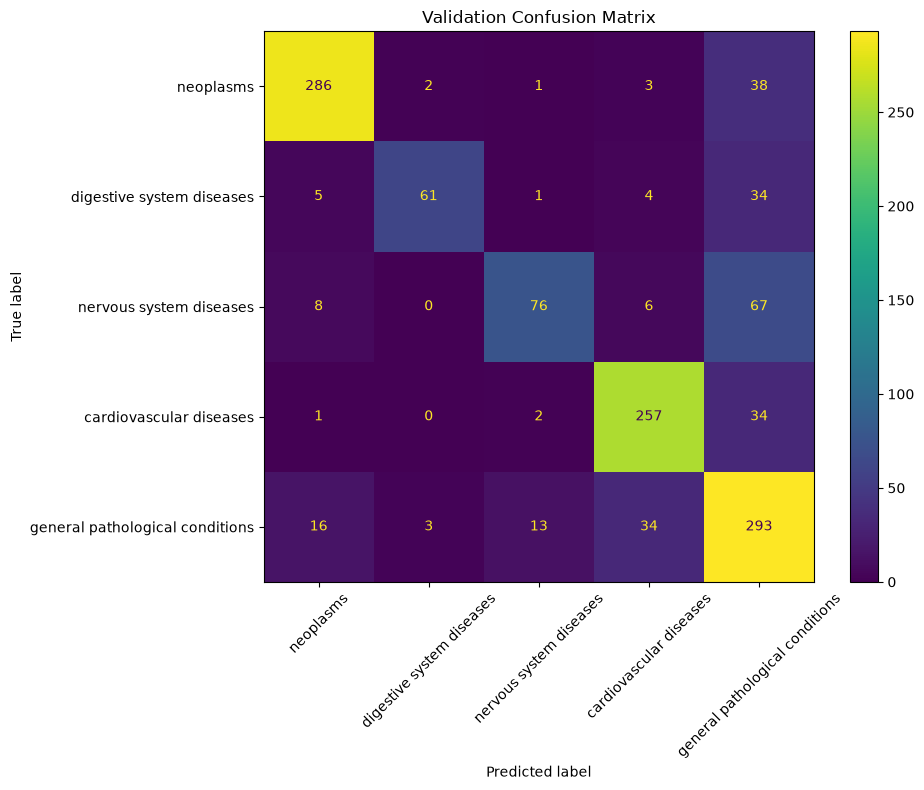

In [26]:
fig, ax = plt.subplots(figsize=(10, 8))

ConfusionMatrixDisplay.from_predictions(
    y_validation,
    validation_predictions,
    labels=label_order,
    display_labels=target_names,
    xticks_rotation=45,
    ax=ax,
)

plt.title("Validation Confusion Matrix")
plt.tight_layout()
plt.show()

In [27]:
errors_df = validation_df.copy()

errors_df["predicted_label"] = validation_predictions

In [28]:
nervous_as_general = errors_df[
    (errors_df[TARGET_COL] == 3)
    & (errors_df["predicted_label"] == 5)
]

print(len(nervous_as_general))

67


In [29]:
for text in nervous_as_general[TEXT_COL].head(5):
    print(text[:1000])
    print("-" * 80)

Interstitial cystitis: successful management by increasing urinary voiding intervals. A variant of the interstitial cystitis (IC) syndrome, minimal or no pain or significant pain that has been lessened by another therapy, can be clinically improved by retraining of the individual's voiding pattern. Patients with greater pain but capable of completing this protocol also may be helped. While this group of patients fills the diagnostic criteria of IC and has many of the classic changes, many differ in that they have minimal or no pain, while simultaneously they have a dysfunctional bladder as expected from long-term low-volume voiding. All patients were placed on a protocol which focused on progressively increasing intervals between voids. Fifteen to thirty minutes initially were added to their present voiding time. The same increase was added to the voiding pattern every three or four weeks until an interval of three to four hours between voids was achieved. Twenty-one patients fit the c

In [31]:
digestive_as_general = errors_df[
    (errors_df[TARGET_COL] == 2)
    & (errors_df["predicted_label"] == 5)
]

print(len(digestive_as_general))

34


### Confusion matrix findings

The confusion matrix reveals a clear error pattern in the baseline model.

Most classification errors are not evenly distributed across the five categories. Instead, examples from several specific condition classes are frequently predicted as **general pathological conditions**.

The strongest confusion occurs for **nervous system diseases**, where 67 out of 157 validation examples are incorrectly classified as general pathological conditions. This explains the low recall previously observed for this category.

A similar pattern appears for **digestive system diseases**, where 34 out of 105 examples are assigned to the general pathological conditions category.

The general pathological conditions class receives 466 predictions in total, but only 293 of them are correct. This large number of false positives explains its relatively low precision.

These results suggest that the main weakness of the baseline is not arbitrary confusion between all medical categories. Instead, the classifier tends to use the broader general pathological category when it cannot confidently distinguish a more specific condition.

The next step is to inspect individual misclassified abstracts to understand which textual patterns may be causing these errors.

## 14. Conclusions and next steps

The TF-IDF + Logistic Regression baseline achieved 0.7815 accuracy and
0.7553 macro F1 on the validation set, outperforming the dummy baseline.

Performance varies across classes. Nervous system diseases and digestive
system diseases have lower recall, and many of their examples are predicted
as general pathological conditions.

The confusion matrix establishes this error pattern, but does not explain
its cause. Class imbalance, vocabulary overlap, and annotation limitations
are hypotheses to investigate.

These results apply to the filtered single-label subset, not the complete
original corpus.

The next experiments will investigate class weighting, word bigrams, and
regularization. Model selection will use validation macro F1, with per-class
precision and recall used to assess tradeoffs. The test set remains reserved
for final evaluation.